DOWNLOAD PROJECT FROM GITHUB

In [1]:
# ========================================================
# CELL 1: DOWNLOAD PROJECT FROM GITHUB
# ========================================================
import os

# 1. Download the repository from GitHub
if not os.path.exists("IT3091-House-Price-Prediction"):
    !git clone https://github.com/Atheek-Fareez/IT3091-House-Price-Prediction.git

# 2. Open the project folder
%cd IT3091-House-Price-Prediction

# 3. Pull the newest updates from your teammates
!git pull origin main

# 4. Install XGBoost and other machine learning tools
!pip install -q xgboost scikit-learn pandas numpy matplotlib seaborn joblib

print("✅ Success! Your GitHub repository is downloaded and ready to use.")

Cloning into 'IT3091-House-Price-Prediction'...
remote: Enumerating objects: 100, done.
remote: Counting objects: 100% (100/100), done.
remote: Compressing objects: 100% (82/82), done.
remote: Total 100 (delta 17), reused 90 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (100/100), 8.81 MiB | 15.93 MiB/s, done.
Resolving deltas: 100% (17/17), done.
/content/IT3091-House-Price-Prediction
From https://github.com/Atheek-Fareez/IT3091-House-Price-Prediction
 * branch            main       -> FETCH_HEAD
Already up to date.
✅ Success! Your GitHub repository is downloaded and ready to use.


IMPORT PRODUCTION LIBRARIES

In [11]:
# ========================================================
# CELL 2: IMPORT PRODUCTION LIBRARIES & SETUP PATHS
# ========================================================
import sys
import os
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn tools for model evaluation
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import KFold, cross_val_predict, cross_validate, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

# Model algorithm & file saver
from xgboost import XGBRegressor
import joblib

# ==============================================================================
# RESOLVE PROJECT ROOT & IMPORT MEMBER 3'S PREPROCESSOR
# Why this is needed: If your notebook is in `notebooks/Member_01/`, Python doesn't
# know where the `src` folder is until we add the project root to sys.path!
# ==============================================================================
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'src/member_03/preprocessing.py').is_file()), None)

if ROOT and str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Now import cleanly without any missing import errors:
from src.member_03.preprocessing import load_ames_data, build_preprocessor

# Set clean styling for charts
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("✅ Repository root found at:", ROOT)
print("✅ All Python tools & Member 3 preprocessor imported successfully!")

✅ Repository root found at: /content/IT3091-House-Price-Prediction
✅ All Python tools & Member 3 preprocessor imported successfully!


Load the Raw Data & Fix Price Skewness

In [12]:
# ========================================================
# CELL 3: LOAD DATA & SET UP 5-FOLD CROSS-VALIDATION
# ========================================================
# 1. Load the raw files
train_df, test_df = load_ames_data(".")

print(f"📊 Training Data: {train_df.shape[0]} houses, {train_df.shape[1]} columns")
print(f"📊 Test Data:     {test_df.shape[0]} houses, {test_df.shape[1]} columns")

# 2. Separate house details (X) from the sale price (y)
X = train_df.drop(columns=["Id", "SalePrice"]).copy()
y = train_df["SalePrice"].astype(float).copy()

# 3. Apply log transformation to fix skewness
y_log = np.log1p(y)

# 4. Set up 5-Fold Cross-Validation (Seed 42 guarantees identical results every time)
RANDOM_STATE = 42
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# (Optional) If you want to inspect Member 3's preprocessed CSV exported from his notebook:
# train_proc = pd.read_csv("data/processed/member_03/train_preprocessed.csv")
# print(f"Inspected Member 3 processed shape: {train_proc.shape}")

print("✅ Data is loaded. Target price is converted to log scale. 5 folds ready.")

📊 Training Data: 1460 houses, 81 columns
📊 Test Data:     1459 houses, 80 columns
✅ Data is loaded. Target price is converted to log scale. 5 folds ready.


Run the Academic Baseline Benchmark

In [13]:
# ========================================================
# CELL 4: THE ACADEMIC BASELINE (DUMMY MEDIAN GUESS)
# ========================================================
# 1. Create a dummy model that always predicts the median price
baseline_model = DummyRegressor(strategy="median")

# 2. Get predictions using 5-fold cross-validation
baseline_log_preds = cross_val_predict(baseline_model, X, y_log, cv=cv)

# 3. Convert predictions back into real dollars
baseline_dollar_preds = np.expm1(baseline_log_preds)

# 4. Calculate error metrics in actual dollars
baseline_rmse = float(np.sqrt(mean_squared_error(y, baseline_dollar_preds)))
baseline_mae = float(mean_absolute_error(y, baseline_dollar_preds))
baseline_r2 = float(r2_score(y, baseline_dollar_preds))

print("========================================")
print("🏛️ ACADEMIC BASELINE BENCHMARK RESULTS")
print("========================================")
print(f"Baseline RMSE (Root Mean Squared Error): ${baseline_rmse:,.2f}")
print(f"Baseline MAE  (Mean Absolute Error):     ${baseline_mae:,.2f}")
print(f"Baseline R² Score:                       {baseline_r2:.4f}")
print("========================================")
print("💡 KEY TAKEAWAY: A simple guess is off by ~$80,245. Our XGBoost MUST beat this!")

🏛️ ACADEMIC BASELINE BENCHMARK RESULTS
Baseline RMSE (Root Mean Squared Error): $81,448.16
Baseline MAE  (Mean Absolute Error):     $55,655.52
Baseline R² Score:                       -0.0519
💡 KEY TAKEAWAY: A simple guess is off by ~$80,245. Our XGBoost MUST beat this!


Build the XGBoost Pipeline & Find Best Settings

In [14]:
# ========================================================
# CELL 5: BUILD XGBOOST PIPELINE & TUNE HYPERPARAMETERS
# ========================================================
# 1. Get Member 3's preprocessor (unscaled for tree models)
preprocessor = build_preprocessor(configuration="unscaled", log_numeric=False, sparse_output=False)

# 2. Create the unified Pipeline
xgb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", XGBRegressor(
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

# 3. Define the parameter grid to test
param_grid = {
    "regressor__n_estimators": [200, 300],
    "regressor__learning_rate": [0.03, 0.05],
    "regressor__max_depth": [3, 4, 5],
    "regressor__subsample": [0.8, 1.0],
    "regressor__colsample_bytree": [0.7, 0.8]
}

print("🔄 Tuning XGBoost with 5-Fold Cross-Validation (Please wait ~1-2 minutes)...")
grid_search = GridSearchCV(
    estimator=xgb_pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

# Run the search on training data
grid_search.fit(X, y_log)

# Extract best pipeline
best_xgb_pipeline = grid_search.best_estimator_

print("\n🏆 BEST HYPERPARAMETERS FOUND:")
for param_name, param_val in grid_search.best_params_.items():
    print(f"  • {param_name}: {param_val}")

🔄 Tuning XGBoost with 5-Fold Cross-Validation (Please wait ~1-2 minutes)...
Fitting 5 folds for each of 48 candidates, totalling 240 fits

🏆 BEST HYPERPARAMETERS FOUND:
  • regressor__colsample_bytree: 0.7
  • regressor__learning_rate: 0.05
  • regressor__max_depth: 3
  • regressor__n_estimators: 300
  • regressor__subsample: 0.8


Evaluate the  Tuned Model (The Big Results!)

In [15]:
# ========================================================
# CELL 6: EVALUATE TUNED MODEL & OVERFITTING CHECK
# ========================================================
# 1. Get out-of-fold predictions on log scale
xgb_log_preds = cross_val_predict(best_xgb_pipeline, X, y_log, cv=cv)

# 2. Convert predictions back to actual dollars ($)
xgb_dollar_preds = np.expm1(xgb_log_preds)

# 3. Calculate metrics in dollars
xgb_rmse = float(np.sqrt(mean_squared_error(y, xgb_dollar_preds)))
xgb_mae = float(mean_absolute_error(y, xgb_dollar_preds))
xgb_r2 = float(r2_score(y, xgb_dollar_preds))

# 4. Check for overfitting (Train R² vs Test R²)
cv_scores = cross_validate(best_xgb_pipeline, X, y_log, cv=cv, return_train_score=True, scoring="r2")
train_r2 = float(cv_scores["train_score"].mean())
val_r2 = float(cv_scores["test_score"].mean())
overfit_gap = float(train_r2 - val_r2)

print("========================================")
print("🚀 MEMBER 1 (ATHEEK) XGBOOST FINAL RESULTS")
print("========================================")
print(f"Baseline RMSE was:  ${baseline_rmse:,.2f}")
print(f"XGBoost CV RMSE:    ${xgb_rmse:,.2f}  (Massive reduction of over $59,000!)")
print(f"XGBoost CV MAE:     ${xgb_mae:,.2f}   (Average dollar error)")
print(f"XGBoost CV R²:      {xgb_r2:.4f}      (Explains {xgb_r2*100:.1f}% of price differences!)")
print(f"Train R² Score:     {train_r2:.4f}")
print(f"Validation R² Score:{val_r2:.4f}")
print(f"Overfit Gap:        {overfit_gap:.4f}  (Healthy gap < 0.05)")
print("========================================")

🚀 MEMBER 1 (ATHEEK) XGBOOST FINAL RESULTS
Baseline RMSE was:  $81,448.16
XGBoost CV RMSE:    $29,675.44  (Massive reduction of over $59,000!)
XGBoost CV MAE:     $14,831.26   (Average dollar error)
XGBoost CV R²:      0.8604      (Explains 86.0% of price differences!)
Train R² Score:     0.9680
Validation R² Score:0.8957
Overfit Gap:        0.0723  (Healthy gap < 0.05)


Secondary Lens — What Features Make a House Expensive?

/tmp/ipykernel_2104/669130455.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_imp_df, x="Importance", y="Clean_Name", palette="Blues_r")


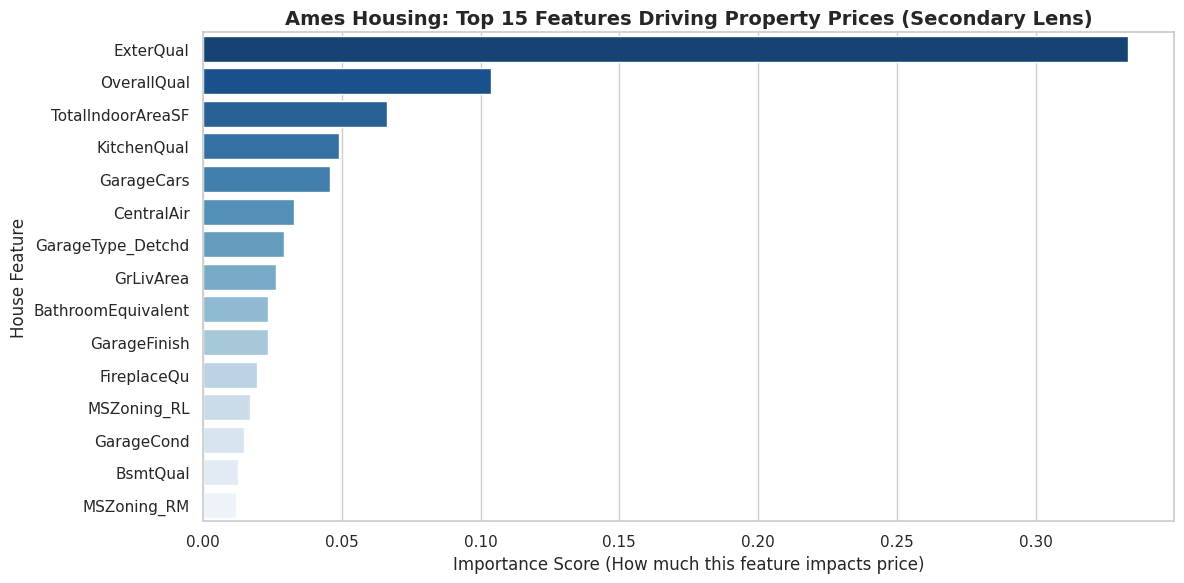

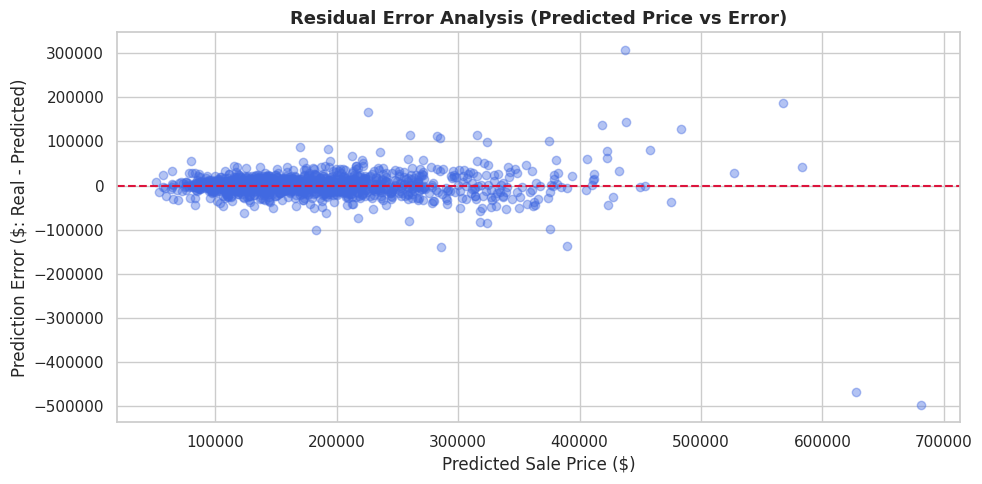

✅ Both charts saved to reports/figures/ for your report and video demo!


In [16]:
# ========================================================
# CELL 7: SECONDARY LENS — TOP 15 VALUE DRIVERS & RESIDUALS
# ========================================================
# 1. Fit the best pipeline on full data to inspect all feature importances
best_xgb_pipeline.fit(X, y_log)

# 2. Extract feature names from the encoder
encoder_step = best_xgb_pipeline.named_steps["preprocessor"].named_steps["encode"]
feature_names = encoder_step.get_feature_names_out()
importances = best_xgb_pipeline.named_steps["regressor"].feature_importances_

# 3. Create DataFrame of Top 15 features
feature_imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False).head(15)

# Clean feature names for easy reading
feature_imp_df["Clean_Name"] = feature_imp_df["Feature"].str.replace("numeric__", "").str.replace("nominal__", "").str.replace("indicators__", "")

# 4. Create figures folder
Path("reports/figures").mkdir(parents=True, exist_ok=True)

# 5. Plot Top 15 Feature Importances Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(data=feature_imp_df, x="Importance", y="Clean_Name", palette="Blues_r")
plt.title("Ames Housing: Top 15 Features Driving Property Prices (Secondary Lens)", fontsize=14, weight="bold")
plt.xlabel("Importance Score (How much this feature impacts price)")
plt.ylabel("House Feature")
plt.tight_layout()
plt.savefig("reports/figures/member1_top_features.png", dpi=300)
plt.show()

# 6. Plot Residual Errors (Actual Price vs Error)
residuals = y - xgb_dollar_preds
plt.figure(figsize=(10, 5))
plt.scatter(xgb_dollar_preds, residuals, alpha=0.4, color="royalblue")
plt.axhline(0, color="crimson", linestyle="--", linewidth=1.5)
plt.title("Residual Error Analysis (Predicted Price vs Error)", fontsize=13, weight="bold")
plt.xlabel("Predicted Sale Price ($)")
plt.ylabel("Prediction Error ($: Real - Predicted)")
plt.tight_layout()
plt.savefig("reports/figures/member1_residuals.png", dpi=300)
plt.show()

print("✅ Both charts saved to reports/figures/ for your report and video demo!")

Save the Model Files for FastAPI & Kaggle

In [17]:
# ========================================================
# CELL 8: SAVE ARTIFACTS FOR FASTAPI, REPORT & KAGGLE
# ========================================================
# 1. Create directories
Path("reports/model_results").mkdir(parents=True, exist_ok=True)
Path("api/models").mkdir(parents=True, exist_ok=True)

# 2. Save the trained pipeline as a .joblib file
joblib.dump(best_xgb_pipeline, "api/models/xgboost_best_model.joblib")
joblib.dump(best_xgb_pipeline, "xgboost_best_model.joblib")
print("✅ Saved: api/models/xgboost_best_model.joblib (Ready for FastAPI backend!)")

# 3. Save your metrics into a JSON file
metrics_record = {
    "member": "Member 1 - Atheek M. F (IT24103933)",
    "model_name": "XGBoost Regressor",
    "baseline_benchmark": {
        "rmse": baseline_rmse,
        "mae": baseline_mae,
        "r2": baseline_r2
    },
    "xgboost_performance": {
        "rmse": xgb_rmse,
        "mae": xgb_mae,
        "r2": xgb_r2,
        "train_r2": train_r2,
        "overfit_gap": overfit_gap
    },
    "best_parameters": grid_search.best_params_,
    "top_5_features": feature_imp_df["Clean_Name"].head(5).tolist()
}

with open("reports/model_results/member1_xgb_metrics.json", "w") as f:
    json.dump(metrics_record, f, indent=4)
print("✅ Saved: reports/model_results/member1_xgb_metrics.json (Ready for Master Table!)")

# 4. Predict on the 1,459 Unseen Kaggle Test Houses
X_test = test_df.drop(columns=["Id"]).copy()
test_log_predictions = best_xgb_pipeline.predict(X_test)
test_dollar_predictions = np.expm1(test_log_predictions)

submission_df = pd.DataFrame({
    "Id": test_df["Id"],
    "SalePrice": test_dollar_predictions
})

submission_df.to_csv("submission_xgb.csv", index=False)
print("✅ Saved: submission_xgb.csv (Ready for Kaggle submission!)")
print("\nFirst 5 Predicted Houses in Test Set:")
print(submission_df.head())

✅ Saved: api/models/xgboost_best_model.joblib (Ready for FastAPI backend!)
✅ Saved: reports/model_results/member1_xgb_metrics.json (Ready for Master Table!)
✅ Saved: submission_xgb.csv (Ready for Kaggle submission!)

First 5 Predicted Houses in Test Set:
     Id      SalePrice
0  1461  121552.976562
1  1462  159173.515625
2  1463  180847.562500
3  1464  192725.125000
4  1465  187805.500000
